In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

source_dir = Path.cwd().parent / "src"
if source_dir.is_dir() and str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))
from onlinecp.utils import feature_functions as feat


In [2]:
# Experiment settings 
D = 20
M = 500
REF_SIZE = 250
PRE_STEPS = 1_000
POST_STEPS = 5_000
N_RUNS = 200
ALPHAS = (0.05,)
KAPPA = 1.0
ETA = 1e-2
LAMBDA0 = LAMBDA1 = 0.999
LAMBDA_CLIP = (0.001, 0.999)
POST_SCALE = 0.3
POST_SEED = 10_000 + 32          
RUN_SEED = 12_345 + 1_000 * 31   

MEAN = np.zeros(D)
COVARIANCE = np.eye(D)
CASE = "Laplace(scale=0.3)"
OUT_DIR = Path("gaussian-laplace-d20-time-depent-threshold")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
class AdaptiveForgettingFactor:

    def __init__(self, feature):
        self.feature = feature
        self.m = self.Lm = None
        self.w = self.Lw = 0.0
        self.k = 0
        self.lam = LAMBDA0
        self.lambdas = []

    def update(self, sample):
        x = self.feature(sample)
        if self.m is None:
            self.m = np.zeros_like(x)
            self.Lm = np.zeros_like(x)

        if self.w:
            old_mean = self.m / self.w
            old_derivative = (self.Lm - old_mean * self.Lw) / self.w
        else:
            old_mean = old_derivative = np.zeros_like(self.m)

        lam = self.lam
        next_m = lam * self.m + x
        next_w = lam * self.w + 1.0
        self.Lm, self.Lw = self.m + lam * self.Lm, self.w + lam * self.Lw
        self.m, self.w = next_m, next_w
        self.lambdas.append(lam)  # lambda used for this observation
        self.k += 1

        if self.k == 1:
            self.lam = float(np.clip(LAMBDA1, *LAMBDA_CLIP))
        else:
            gradient = 2.0 * float(np.dot(old_derivative.ravel(), (old_mean - x).ravel()))
            self.lam = float(np.clip(lam - ETA * gradient, *LAMBDA_CLIP))

        mean = self.m / self.w
        return float(np.vdot(mean, mean).real)


def make_feature(rng):
    """Fresh reference sample and half-off-diagonal median bandwidth."""
    reference = rng.normal(size=(REF_SIZE, D))
    subset = reference[np.random.default_rng(1234).choice(REF_SIZE, size=min(REF_SIZE, 500), replace=True)]
    norms = np.sum(subset * subset, axis=1)
    distances = np.maximum(norms[:, None] + norms[None, :] - 2.0 * subset @ subset.T, 0.0)
    sigma_sq = float(0.5 * np.median(distances[np.triu_indices(len(subset), k=1)]))
    weights, sigma_sq = feat.generate_frequencies(M, D, choice_sigma="fixed", sigmasq=sigma_sq)
    return lambda x: feat.fourier_feat(x, weights), float(sigma_sq)


def threshold(t, alpha, theta):
    """Original equal-weight Gaussian-kernel theoretical threshold."""
    t = np.asarray(t, dtype=float)
    bucket = np.floor(np.log2(t))
    log_factor = bucket * np.log(2.0) + 2.0 * np.log(bucket + 1.0)
    log_factor += np.log(2.0 * np.pi**2 / (3.0 * alpha))
    L_t = (4.0 * t - 3.0) ** 2 / t**3
    expected = 1.0 / t + (1.0 - 1.0 / t) * theta
    epsilon = KAPPA * np.sqrt((L_t / 2.0) * log_factor)
    return expected, epsilon


In [4]:
def run_experiment():
    """Run the Laplace post-change experiment, retaining all trajectories."""
    if REF_SIZE < 2 or POST_STEPS < 1 or N_RUNS < 1:
        raise ValueError("REF_SIZE >= 2, POST_STEPS >= 1 and N_RUNS >= 1 are required")
    if COVARIANCE.shape != (D, D) or MEAN.shape != (D,):
        raise ValueError("MEAN/COVARIANCE must match D")
    if not ALPHAS or any(not 0 < a < 1 for a in ALPHAS):
        raise ValueError("Each alpha must lie strictly between 0 and 1")

    total = PRE_STEPS + POST_STEPS
    time = np.arange(1, total + 1)
    rng = np.random.default_rng(RUN_SEED)
    post_rng = np.random.default_rng(POST_SEED)
    cholesky = np.linalg.cholesky(COVARIANCE)
    stats = np.empty((N_RUNS, total))
    lambdas = np.empty_like(stats)
    sigmas = np.empty(N_RUNS)
    thetas = np.empty(N_RUNS)
    delays = np.empty((N_RUNS, len(ALPHAS)), dtype=int)
    censored = np.zeros(len(ALPHAS), dtype=int)
    bands = {a: {k: np.zeros(total) for k in ("expected", "lower", "upper")} for a in ALPHAS}

    for run in tqdm(range(N_RUNS), desc=CASE):
        feature_rng = np.random.default_rng(rng.integers(0, 2**63 - 1))
        feature, sigmas[run] = make_feature(feature_rng)
        sign, logdet = np.linalg.slogdet(np.eye(D) + 2.0 * COVARIANCE / sigmas[run])
        if sign <= 0:
            raise ValueError("The Gaussian-kernel theory matrix must be positive definite")
        thetas[run] = np.exp(-0.5 * logdet)

        pre_rng = np.random.default_rng(rng.integers(0, 2**63 - 1))
        pre = MEAN + pre_rng.standard_normal((PRE_STEPS, D)) @ cholesky.T
        post = post_rng.laplace(scale=POST_SCALE, size=(POST_STEPS, D))
        detector = AdaptiveForgettingFactor(feature)
        stats[run] = [detector.update(x) for x in np.concatenate((pre, post))]
        lambdas[run] = detector.lambdas

        for j, alpha in enumerate(ALPHAS):
            expected, epsilon = threshold(time, alpha, thetas[run])
            bands[alpha]["expected"] += expected
            bands[alpha]["lower"] += expected - epsilon
            bands[alpha]["upper"] += expected + epsilon
            hit = np.flatnonzero(np.abs(stats[run, PRE_STEPS:] - expected[PRE_STEPS:]) > epsilon[PRE_STEPS:])
            delays[run, j] = int(hit[0] + 1) if hit.size else POST_STEPS + 1
            censored[j] += not hit.size

    for case_bands in bands.values():
        for values in case_bands.values():
            values /= N_RUNS
    return stats, lambdas, sigmas, thetas, delays, censored, bands


stats, lambdas, sigmas, thetas, delays, censored, bands = run_experiment()


Laplace(scale=0.3): 100%|██████████| 200/200 [00:54<00:00,  3.64it/s]


In [5]:
# Save EDD summary as CSV.
rows = []
for j, alpha in enumerate(ALPHAS):
    dly = delays[:, j].astype(float)
    edd_var = float(dly.var(ddof=1)) if N_RUNS > 1 else 0.0
    rows.append({
        "post_change_name": CASE, "alpha": alpha, "dimension_d": D,
        "pre_change_length": PRE_STEPS,
        "detector_kernel_sigmasq_method3_mean": float(sigmas.mean()),
        "detector_kernel_sigmasq_method3_std": float(sigmas.std(ddof=1)) if N_RUNS > 1 else 0.0,
        "theta_K_method3_mean": float(thetas.mean()),
        "theta_K_method3_std": float(thetas.std(ddof=1)) if N_RUNS > 1 else 0.0,
        "edd_hat_method3": float(dly.mean()),
        "edd_std_method3": np.sqrt(edd_var),
        "edd_se_mean_method3": np.sqrt(edd_var / N_RUNS),
        "edd_censored_rate_method3": float(censored[j] / N_RUNS),
    })

summary_df = pd.DataFrame(rows)
base_cols = ("post_change_name", "alpha", "dimension_d", "pre_change_length")
method_df = summary_df[[c for c in summary_df if c in base_cols or c.endswith("_method3")]].rename(
    columns=lambda c: c.removesuffix("_method3")
)
method_csv = OUT_DIR / "edd-gaussian-laplace-d20.csv"
method_df.to_csv(method_csv, index=False)

print(f"Saved: {method_csv}")
display(method_df)


Saved: gaussian-laplace-d20-time-depent-threshold/edd-gaussian-laplace-d20.csv


,post_change_name,alpha,dimension_d,pre_change_length,edd_hat,edd_std,edd_se_mean,edd_censored_rate
0,Laplace(scale=0.3),0.05,20,1000,27.005,2.777327,0.196387,0.0


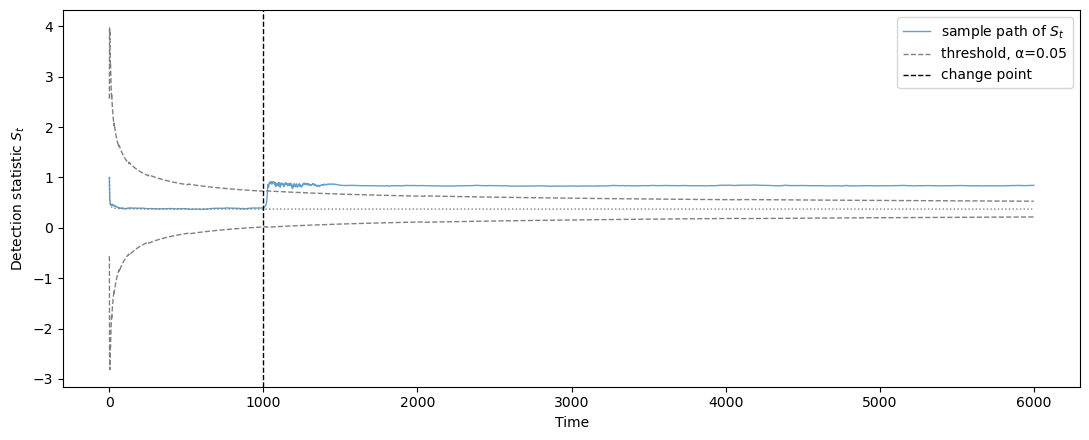

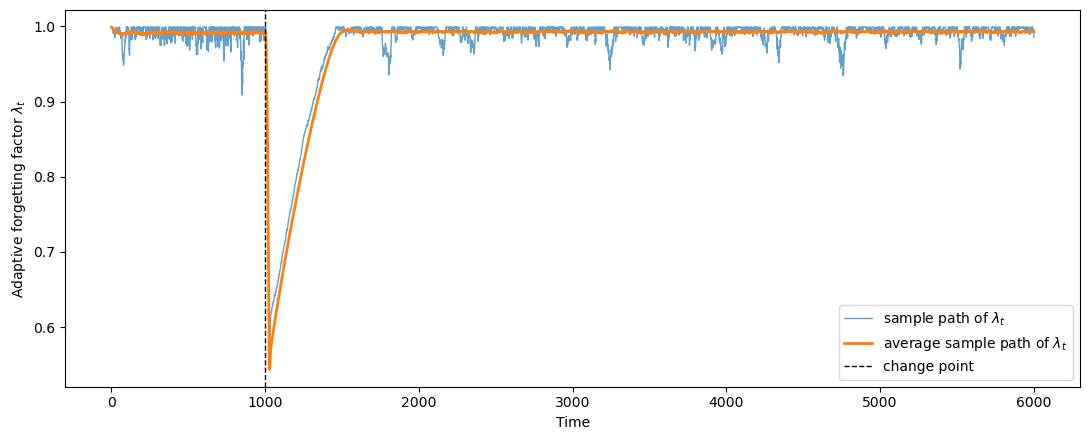

In [6]:
def plot_paths(values, ylabel, filename, threshold_bands=None, *, path_label, mean_label=None):
    """Plot a sample path, optionally including its Monte Carlo mean."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    time = np.arange(1, values.shape[1] + 1)
    ax.plot(time, values[0], lw=1, alpha=0.7, label=path_label)
    if mean_label is not None:
        ax.plot(time, values.mean(axis=0), lw=2, label=mean_label)
    if threshold_bands is not None:
        for alpha, band in threshold_bands.items():
            ax.plot(time, band["lower"], "--", color="grey", lw=1, label=f"threshold, α={alpha:g}")
            ax.plot(time, band["upper"], "--", color="grey", lw=1)
            ax.plot(time, band["expected"], ":", color="grey", lw=1)
    ax.axvline(PRE_STEPS, ls="--", color="black", lw=1, label="change point")
    ax.set(xlabel="Time", ylabel=ylabel)
    ax.legend(loc="best")
    fig.tight_layout()
    filename.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    fig.savefig(filename.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()


figure_dir = OUT_DIR / "figures" / "Laplacescale0.3"
plot_paths(
    stats, r"Detection statistic $S_t$", figure_dir / "statistic.png", bands,
    path_label=r"sample path of $S_t$",
)
plot_paths(
    lambdas, r"Adaptive forgetting factor $\lambda_t$", figure_dir / "lambda.png",
    path_label=r"sample path of $\lambda_t$",
    mean_label=r"average sample path of $\lambda_t$",
)
